In [2]:
import SAIfunc_20260217 as sai
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler
from pathlib import Path

In [3]:
simlog = pd.read_csv('simlog.csv', index_col='timestamp')
selected = simlog[
    (simlog['nV']==40) & (simlog['p0']==0.5) & (simlog['pE']==0.1)
]

In [6]:
a0s = sorted(set(selected['a0']))
a1s = sorted(set(selected['a1']))

violin_kwargs = {
    'orientation':'horizontal', 
    'positions':[0], 
    'widths':1, 
    'showmeans':True, 
    'quantiles':[0.25, 0.5, 0.75], 
    'points':40
}

plt.rcParams['axes.prop_cycle'] = cycler(
    color=[(1,.1,.1, 0.7), (.1,.1,1, 0.7)]
)

Read 500 from data/SAIsim-20260401_054513.npz 
 {'nV': 40, 'p0': 0.5, 'pE': 0.1, 'a0': 0.25, 'a1': 0.25}
Read 500 from data/SAIsim-20260401_054519.npz 
 {'nV': 40, 'p0': 0.5, 'pE': 0.1, 'a0': 0.25, 'a1': 0.5}
Read 500 from data/SAIsim-20260401_054524.npz 
 {'nV': 40, 'p0': 0.5, 'pE': 0.1, 'a0': 0.25, 'a1': 1.0}
Read 500 from data/SAIsim-20260401_054530.npz 
 {'nV': 40, 'p0': 0.5, 'pE': 0.1, 'a0': 0.25, 'a1': 2.0}
Read 500 from data/SAIsim-20260401_054535.npz 
 {'nV': 40, 'p0': 0.5, 'pE': 0.1, 'a0': 0.25, 'a1': 4.0}
Read 500 from data/SAIsim-20260401_054552.npz 
 {'nV': 40, 'p0': 0.5, 'pE': 0.1, 'a0': 0.5, 'a1': 0.25}
Read 500 from data/SAIsim-20260401_054558.npz 
 {'nV': 40, 'p0': 0.5, 'pE': 0.1, 'a0': 0.5, 'a1': 0.5}
Read 500 from data/SAIsim-20260401_054604.npz 
 {'nV': 40, 'p0': 0.5, 'pE': 0.1, 'a0': 0.5, 'a1': 1.0}
Read 500 from data/SAIsim-20260401_054613.npz 
 {'nV': 40, 'p0': 0.5, 'pE': 0.1, 'a0': 0.5, 'a1': 2.0}
Read 500 from data/SAIsim-20260401_054620.npz 
 {'nV': 40, 'p0': 0

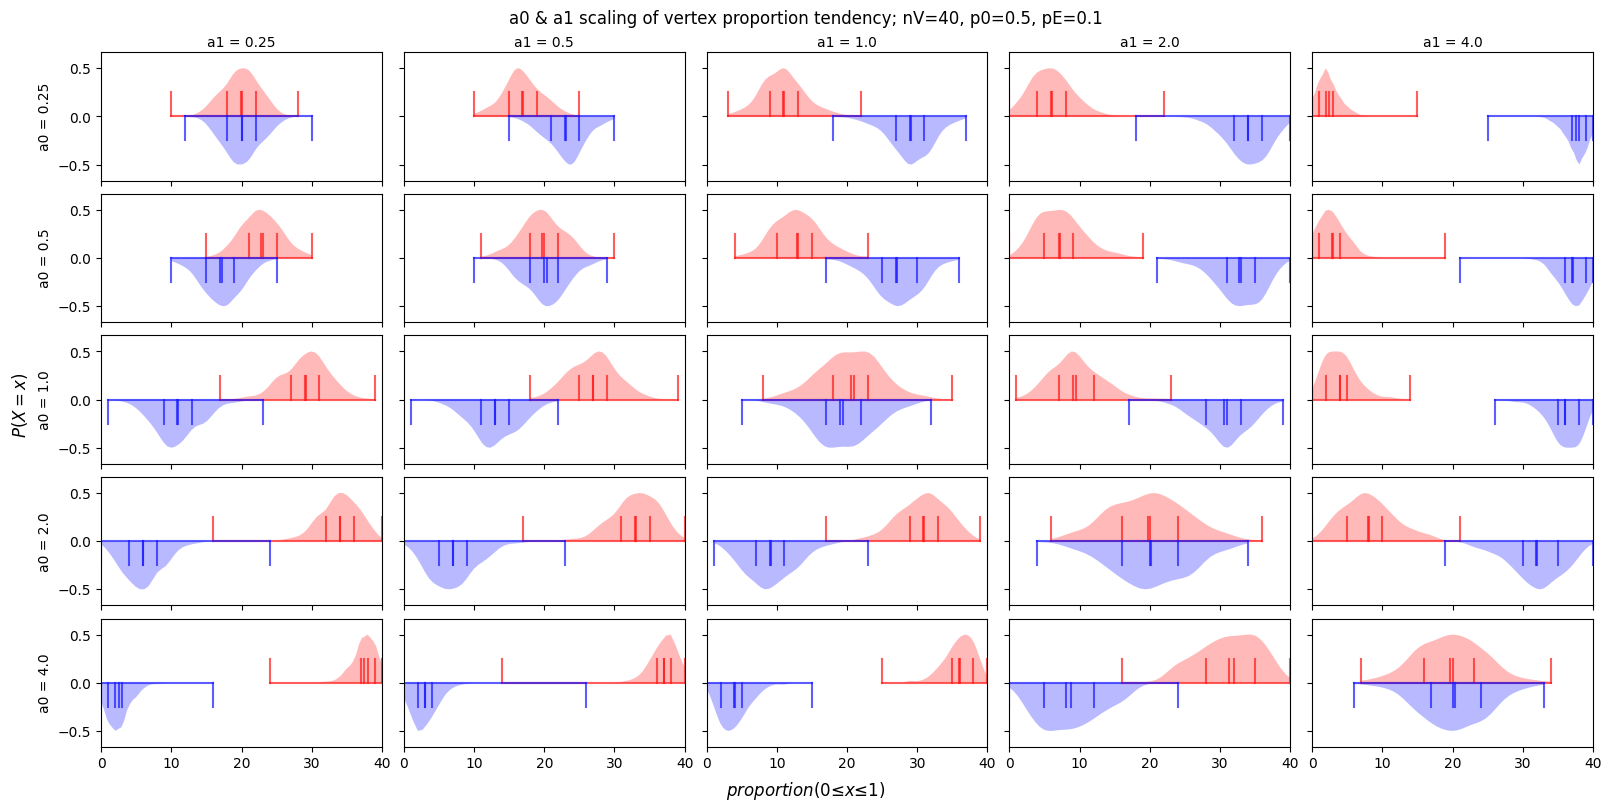

In [9]:
# a0 down rows, a1 across columns
f, axs = plt.subplots(len(a0s), len(a1s), figsize=(16,8), sharex=True, sharey=True, constrained_layout=True)
f.suptitle('a0 & a1 scaling of vertex proportion tendency; nV=40, p0=0.5, pE=0.1')
'of vertex proportion'
f.supxlabel('$proportion (0 ≤ x ≤ 1)$'), f.supylabel('$P(X = x)$')

for i,ax in enumerate(axs[:, 0]):
    ax.set_ylabel(f'a0 = {a0s[i]}')
for i,ax in enumerate(axs[0,:]):
    ax.xaxis.set_label_position('top')
    ax.set_xlabel(f'a1 = {a1s[i]}')

for id in selected.index:
    a0,a1 = selected.loc[id, ['a0','a1']]
    ax = axs[a0s.index(a0), a1s.index(a1)] 

    v = sai.Sim.fromfile(selected.loc[id, 'location'], 1).all()[0]
    v1 = np.count_nonzero(v, axis=1)
    v0 = 40 - v1

    ax.set(xlim=(0,40), ylim=(-2/3, 2/3))
    components_v0 = ax.violinplot(v0, side='high', **violin_kwargs)
    components_v1 = ax.violinplot(v1, side='low', **violin_kwargs)

    # ft = np.fft.rfft(v1)
    # ax.set(xlim=(0, 1+len(v1)//2), ylim=(0, 2))
    # ax.scatter(
    #     np.arange(1, 1+len(v1)//2), 
    #     np.abs(2 * ft[1:])/len(v1),
    #     s=5, marker='.',
    #     c=[(a0s.index(a0)/5, a1s.index(a1)/5, 0)]
    # )

f.savefig('vproportion-ascaling.svg')